# Test 1 — Річний огляд платежів (2022)

**Мета:** подивитись на платежі за 2022 рік, знайти тренди й аномалії, запропонувати, що робити бізнесу.

**План:**
1. Завантажити й почистити дані
2. Описова статистика
3. Динаміка по місяцях
4. Помилки платежів
5. Аномалії (банки, код 4.05, RuPay)
6. Висновки й рекомендації

In [92]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Завантаження й підготовка даних

In [93]:
df = pd.read_csv("../data/test_1_payment_data/test_1_payment_data.csv")
df = df.drop(columns=['#'], errors='ignore')
df.head()

,order_id,event_time,user_id,price,payment_number,transaction_status,card_brand,card_type,bank_name,error_type,currency,card_country
0,c500aa10-30f8-4927-96c5-4e97b6afac83,2022-07-08 18:32:39.000000,c1ed5188-caac-4d56-bad8-bc8ee0b09960,21.00,reccurent,fail,VISA,PREPAID,ADVANCED BANK OF ASIA LIMITED,3.08,USD,KHM
1,624d6f30-c1bc-4778-a23e-6a227bac73ac,2022-06-09 22:18:36.000000,c9ff65b8-75e6-467f-8715-21edb5fd06af,36.00,reccurent,fail,VISA,PREPAID,UNITED BANK FOR AFRICA GHANA LIMITED,3.02,USD,GHA
2,4d75ca57-8883-49a9-b150-1ab7a47d12f8,2022-06-09 11:18:32.000000,1005d4fb-1b7d-4715-835f-4d2a9bfe7cbb,36.00,initial,success,VISA,CREDIT,ICICI BANK LTD,NaN,USD,IND
3,3fd11eed-4236-46aa-8f21-3c1e1a17a1bc,2022-06-29 13:50:47.000000,866c4b2b-0285-43aa-98bd-d60bc3a78d7c,36.00,reccurent,fail,VISA,DEBIT,THE TORONTO-DOMINION BANK,3.02,USD,CAN
4,3b19657f-1a34-4233-b25c-5d3b7fb32782,2022-06-17 15:16:47.000000,bd2e4137-5526-4d9b-9dde-7482087fc321,9.00,reccurent,success,MASTERCARD,CREDIT,"CAPITAL ONE BANK (USA), NATIONAL ASSOCIATION",NaN,USD,USA


In [94]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 566413 entries, 0 to 566412
Data columns (total 12 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   order_id            566413 non-null  str    
 1   event_time          566413 non-null  str    
 2   user_id             566413 non-null  str    
 3   price               566413 non-null  float64
 4   payment_number      566413 non-null  str    
 5   transaction_status  566413 non-null  str    
 6   card_brand          566413 non-null  str    
 7   card_type           565643 non-null  str    
 8   bank_name           564404 non-null  str    
 9   error_type          313048 non-null  float64
 10  currency            566413 non-null  str    
 11  card_country        565886 non-null  str    
dtypes: float64(2), str(10)
memory usage: 51.9 MB


Значення `payment_number` у даних написано з помилкою: `reccurent`. Залишаємо як є, щоб не ламати фільтри.

In [95]:
# Шукаємо повні дублікати рядків і видаляємо їх
print("Дублікатів:", df.duplicated().sum())
df = df.drop_duplicates()

# Дата й час -> формат дати, і додаємо корисні колонки
df['event_time'] = pd.to_datetime(df['event_time'])
df['month'] = df['event_time'].dt.month
df['weekday'] = df['event_time'].dt.dayofweek    # 0 = понеділок, 6 = неділя

# 1 якщо платіж успішний, 0 якщо ні
df['is_success'] = (df['transaction_status'] == 'success').astype(int)

# Дохід = сума лише успішних платежів (у валюті платежу)
df['revenue'] = df['price'] * df['is_success']

Дублікатів: 1098


# 2. Описова статистика

In [96]:
print("Транзакцій:", len(df))
print("Унікальних користувачів:", df['user_id'].nunique())
print("Success rate, %:", round(df['is_success'].mean() * 100, 1))

df.isnull().sum()

Транзакцій: 565315
Унікальних користувачів: 115245
Success rate, %: 44.5


order_id                   0
event_time                 0
user_id                    0
price                      0
payment_number             0
transaction_status         0
card_brand                 0
card_type                770
bank_name               2006
error_type            252297
currency                   0
card_country             527
month                      0
weekday                    0
is_success                 0
revenue                    0
dtype: int64

In [97]:
# Скільки платежів у кожному статусі та типі
print(df['transaction_status'].value_counts())
print()
print(df['payment_number'].value_counts())

transaction_status
fail       313924
success    251391
Name: count, dtype: int64

payment_number
reccurent    423065
initial      142250
Name: count, dtype: int64


## Валюти

У даних є USD і EUR. Курсу в завданні немає, тому суми **не складаємо**, а рахуємо окремо по кожній валюті.

In [98]:
by_currency = df.groupby('currency').agg(
    transactions=('order_id', 'count'),
    success_rate=('is_success', 'mean'),
    revenue=('revenue', 'sum')
)
by_currency['success_rate'] = (by_currency['success_rate'] * 100).round(1)
by_currency

,transactions,success_rate,revenue
currency,,,
EUR,48125,45.60,"483,492.00"
USD,517190,44.40,"5,069,542.00"


## Success rate за типом картки, брендом і країною

In [99]:
# Рахуємо кількість платежів і success rate для будь-якої колонки
def sr_by(col):
    t = df.groupby(col).agg(transactions=('order_id', 'count'), success_rate=('is_success', 'mean'))
    t['success_rate'] = (t['success_rate'] * 100).round(1)
    return t.sort_values('transactions', ascending=False)

display(sr_by('card_type'))
display(sr_by('card_brand'))
display(sr_by('card_country').head(10))

,transactions,success_rate
card_type,,
DEBIT,369318,45.50
CREDIT,140143,51.60
PREPAID,53388,18.60
DEFERRED DEBIT,1164,75.60
CREDIT/DEBIT,518,34.00
CHARGE CARD,14,85.70


,transactions,success_rate
card_brand,,
VISA,362544,44.60
MASTERCARD,191271,45.10
AMEX,6883,39.60
DISCOVER,1912,32.00
RUPAY,1575,0.00
MAESTRO,537,5.40
DINERS CLUB,204,17.20
VERVE,201,0.00
CHINA UNIONPAY,74,0.00


,transactions,success_rate
card_country,,
USA,240208,42.50
CAN,36671,50.70
AUS,34416,52.90
IND,28327,30.90
MEX,17621,29.70
GBR,15268,53.50
NZL,10394,52.30
ROU,8328,49.10
SGP,7650,62.50


**Що видно:** у PREPAID-карток success rate набагато нижчий, ніж у DEBIT і CREDIT. У бренду RuPay success rate 0% (розберемо нижче).

# 3. Динаміка по місяцях

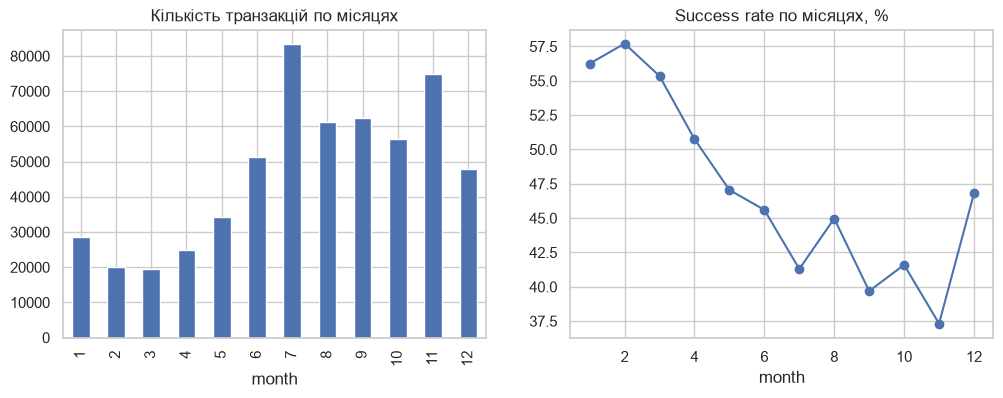

,transactions,success_rate
month,,
1,28664,56.30
2,20150,57.70
3,19449,55.30
4,24757,50.80
5,34336,47.00
6,51441,45.60
7,83338,41.30
8,61363,45.00
9,62414,39.70


In [100]:
monthly = df.groupby('month').agg(
    transactions=('order_id', 'count'),
    success_rate=('is_success', 'mean')
)
monthly['success_rate'] = monthly['success_rate'] * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
monthly['transactions'].plot(kind='bar', ax=axes[0], title='Кількість транзакцій по місяцях')
monthly['success_rate'].plot(marker='o', ax=axes[1], title='Success rate по місяцях, %')
plt.show()

monthly.round(1)

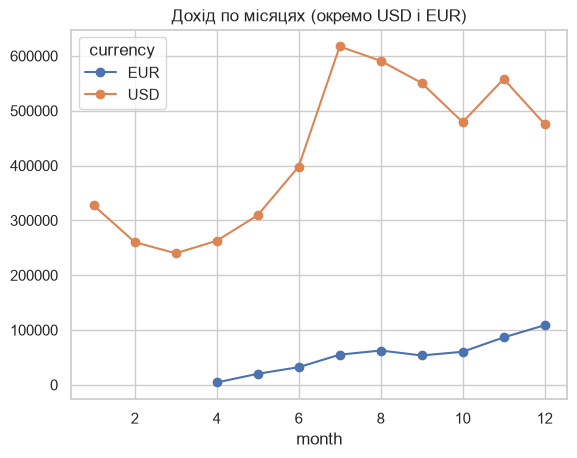

Перша EUR-транзакція: 2022-04-08 16:32:31


In [101]:
# Дохід по місяцях, окремо для кожної валюти
revenue_month = df.pivot_table(index='month', columns='currency', values='revenue', aggfunc='sum')
revenue_month.plot(marker='o', title='Дохід по місяцях (окремо USD і EUR)')
plt.show()

# У який місяць з'явилась перша EUR-транзакція
print("Перша EUR-транзакція:", df.loc[df['currency'] == 'EUR', 'event_time'].min())

**Що видно:** обсяг платежів росте (пік у липні), а success rate падає до кінця року, але в грудні трохи відновлюється. EUR з'являється лише з квітня.

## Initial vs Recurrent

`initial` — перший платіж користувача, `reccurent` — повторне списання з підписки.

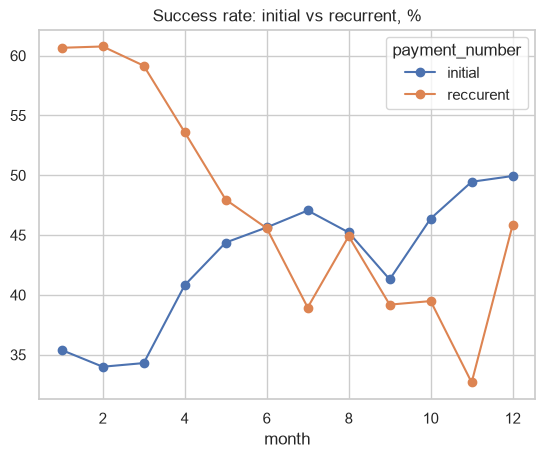

payment_number
reccurent   74.80
initial     25.20
Name: proportion, dtype: float64


In [102]:
sr_type = df.pivot_table(index='month', columns='payment_number', values='is_success', aggfunc='mean') * 100
sr_type.plot(marker='o', title='Success rate: initial vs recurrent, %')
plt.show()

# Яку частку становлять recurrent
print((df['payment_number'].value_counts(normalize=True) * 100).round(1))

**Що видно:** для initial success rate росте протягом року, а для recurrent падає. Recurrent — приблизно 75% усіх платежів, тому саме він визначає загальну картину.

Причину падіння recurrent ми з цих даних **точно не знаємо**. Гіпотези: у користувачів частіше немає коштів на картці (дивимось помилки нижче), змінились налаштування антифроду.

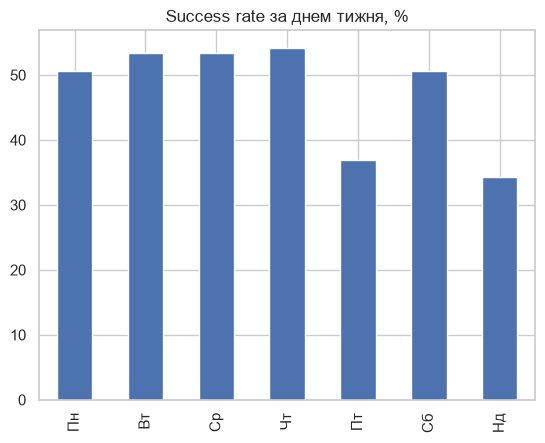

In [103]:
# Success rate за днем тижня
weekday_sr = df.groupby('weekday')['is_success'].mean() * 100
weekday_sr.index = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Нд']
weekday_sr.plot(kind='bar', title='Success rate за днем тижня, %')
plt.show()

**Що видно:** success rate помітно відрізняється по днях тижня. Чому саме, тут не з'ясовано (можливо, впливає розклад списань підписок). Це можна дослідити далі.

# 4. Помилки платежів

Розшифровка кодів за документацією Solidgate (docs.solidgate.com → Error codes). Я додав лише коди, які звірив із документацією. Для інших у таблиці буде «опис не додано».

In [114]:
error_names = {
    '0.01': 'General decline (загальна відмова)',
    '0.02': 'Order expired (час замовлення вичерпано)',
    '0.03': 'Illegal operation (незаконна операція)',
    '0.04': 'Payment declined by routing rules (платіж відхилено правилами маршрутизації)',

    '1.01': 'Authentication failed (помилка автентифікації)',

    '2.01': 'Invalid data / Order not found (недійсні дані / замовлення не знайдено)',
    '2.06': 'Invalid CVV (недійсний CVV)',
    '2.07': 'Request is empty (запит порожній)',
    '2.08': 'Invalid card number (недійсний номер картки)',
    '2.09': 'Invalid expiration date (недійсна дата закінчення терміну дії)',
    '2.10': 'Invalid 3DS flow on merchant side (недійсний 3DS процес на стороні мерчанта)',
    '2.11': 'Invalid 3DS flow on bank side (недійсний 3DS процес на стороні банку)',
    '2.15': 'SCA require 3D authentication (SCA вимагає 3D-автентифікацію)',

    '3.01': 'Card is blocked (картку заблоковано)',
    '3.02': 'Insufficient funds (недостатньо коштів)',
    '3.03': 'Payment amount limit excess (перевищено ліміт суми платежу)',
    '3.04': 'Transaction is declined by issuer (транзакцію відхилено емітентом)',
    '3.05': 'Call your bank (зателефонуйте до свого банку)',
    '3.06': 'Debit card not supported (дебетова картка не підтримується)',
    '3.07': 'Card brand is not supported (бренд картки не підтримується)',
    '3.08': 'Do not honor (відхилено / не обслуговувати)',
    '3.09': '3D Secure authentication required (потрібна 3D Secure автентифікація)',
    '3.10': 'Suspected fraud (підозра на шахрайство)',
    '3.11': 'Recurring payment cancelled (регулярний платіж скасовано)',
    '3.12': 'Closed account (закритий рахунок)',

    '4.01': 'Card is in a black list (картка в чорному списку)',
    '4.02': 'Stolen card (викрадена картка)',
    '4.03': 'Restricted card (обмежена картка)',
    '4.04': 'Lost card (втрачена картка)',
    '4.05': 'PSP antifraud (антифрод платіжного провайдера)',
    '4.06': 'Blocked by country/IP (заблоковано за країною / IP)',
    '4.07': 'Trusted antifraud system (заблоковано довіреною антифрод системою)',

    '5.02': 'Invalid card token (недійсний токен картки)',
    '5.03': 'Application error (помилка додатку)',
    '5.04': 'Merchant is not configured correctly (мерчант налаштований неправильно)',
    '5.05': 'Merchant is not activated yet (мерчант ще не активований)',
    '5.06': 'Duplicate order (дублювання замовлення)',
    '5.07': 'Exceeded API calls limits (перевищено ліміт API-запитів)',
    '5.08': 'Invalid transaction (недійсна транзакція)',
    '5.09': 'Merchant not found (мерчанта не знайдено)',
    '5.10': 'Processor does not support requested API method (процесор не підтримує запитаний метод API)',
    '5.11': 'Invalid routing (недійсна маршрутизація)',
    '5.12': 'Account is blocked (акаунт заблоковано)',

    '6.01': 'Unknown decline code (невідомий код відмови)',
    '6.02': 'Connection error (помилка з\'єднання)',
    '6.03': 'Processing issue (проблема обробки)',

    '7.01': 'Card token not found (токен картки не знайдено)'
}

fails = df[df['transaction_status'] == 'fail']

top_errors = fails['error_type'].value_counts().head(10).to_frame('count')
top_errors['share_of_fails_%'] = (top_errors['count'] / len(fails) * 100).round(1)
top_errors['опис'] = [error_names.get(f"{float(code):.2f}", 'опис не додано') for code in top_errors.index]
top_errors

,count,share_of_fails_%,опис
error_type,,,
3.02,134688,42.90,Insufficient funds (недостатньо коштів)
3.10,43992,14.00,Suspected fraud (підозра на шахрайство)
3.08,26439,8.40,Do not honor (відхилено / не обслуговувати)
3.04,15162,4.80,Transaction is declined by issuer (транзакцію ...
4.03,12796,4.10,Restricted card (обмежена картка)
4.05,12772,4.10,PSP antifraud (антифрод платіжного провайдера)
3.01,12658,4.00,Card is blocked (картку заблоковано)
2.08,8723,2.80,Invalid card number (недійсний номер картки)
0.01,8465,2.70,General decline (загальна відмова)


**Що видно:** найчастіша причина відмови — код 3.02 «недостатньо коштів» (приблизно 43% усіх відмов). Далі йде 3.10 «підозра на шахрайство» (~14%).

За документацією Solidgate 3.02 — *soft decline* (можна пробувати ще раз пізніше), а 3.10, 4.05, 4.09 — *hard decline* (повторювати не варто).

In [105]:
# Чи допомагають повторні спроби в межах одного дня?
df = df.sort_values('event_time')
df['date'] = df['event_time'].dt.date

# номер спроби користувача за день: 1, 2, 3...
df['attempt_in_day'] = df.groupby(['user_id', 'date']).cumcount() + 1
df['attempt_group'] = df['attempt_in_day'].clip(upper=3)     # 3 означає «3 і більше»

attempts = df.groupby('attempt_group')['is_success'].agg(['count', 'mean'])
attempts['mean'] = (attempts['mean'] * 100).round(1)
attempts.columns = ['transactions', 'success_rate_%']
attempts

,transactions,success_rate_%
attempt_group,,
1,492181,45.60
2,54841,41.60
3,18293,21.30


**Що видно:** з кожною наступною спробою за день success rate падає. Тобто «довбити» картку повторами одразу — поганий варіант.

# 5. Аномалії

## 5.1 Банки з низьким success rate

In [106]:
banks = df.groupby('bank_name').agg(
    transactions=('order_id', 'count'),
    success_rate=('is_success', 'mean'),
    prepaid_share=('card_type', lambda s: (s == 'PREPAID').mean())
)
banks['success_rate'] = (banks['success_rate'] * 100).round(1)
banks['prepaid_share'] = (banks['prepaid_share'] * 100).round(1)

# Беремо лише великі банки (5000+ транзакцій) і сортуємо від найгіршого success rate
big_banks = banks[banks['transactions'] >= 5000].sort_values('success_rate')
big_banks.head(10)

,transactions,success_rate,prepaid_share
bank_name,,,
SUTTON BANK,29352,15.20,96.20
METABANK,5356,20.40,66.30
"STRIDE BANK, NATIONAL ASSOCIATION",9502,24.50,11.40
THE BANCORP BANK,14651,27.50,16.40
REVOLUT LIMITED,5347,29.00,0.00
BBVA BANCOMER S.A.,6151,35.30,0.00
THE TORONTO-DOMINION BANK,6777,41.70,0.00
"CAPITAL ONE BANK (USA), NATIONAL ASSOCIATION",6941,51.30,0.00
COMMONWEALTH BANK OF AUSTRALIA,12178,52.30,1.00


**Що видно:** найгірший success rate у SUTTON BANK (≈15% при 5% усього трафіку). Майже всі його картки — PREPAID. Низькі показники також у THE BANCORP BANK, STRIDE BANK, METABANK, REVOLUT.

In [107]:
# SUTTON BANK по місяцях
sutton = df[df['bank_name'] == 'SUTTON BANK']

sutton_month = sutton.groupby('month').agg(
    transactions=('order_id', 'count'),
    users=('user_id', 'nunique'),
    success_rate=('is_success', 'mean')
)
sutton_month['success_rate'] = (sutton_month['success_rate'] * 100).round(1)
sutton_month['tx_per_user'] = (sutton_month['transactions'] / sutton_month['users']).round(1)
sutton_month

,transactions,users,success_rate,tx_per_user
month,,,,
1,828,552,1.90,1.50
2,437,310,2.10,1.40
3,599,399,2.80,1.50
4,1000,640,4.00,1.60
5,1274,795,3.60,1.60
6,997,619,2.30,1.60
7,1110,738,1.20,1.50
8,1339,855,5.50,1.60
9,4389,1530,10.90,2.90


**Що видно:** у вересні–листопаді кількість платежів SUTTON BANK різко росте, а кожен користувач робить більше спроб. Це може бути, наприклад, перебір карт, але з наших даних це не доводиться. Варто перевірити.

## 5.2 Код 4.05 (антифрод платіжного провайдера)

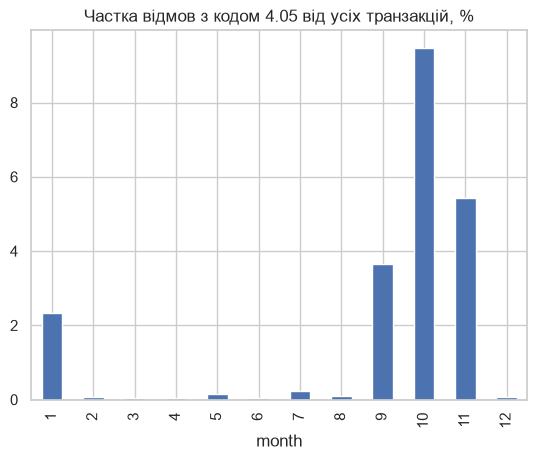

Відмов 4.05 усього: 12772 | у вер–лис: 11705


bank_name
JPMORGAN CHASE BANK N.A.            12.00
BBVA BANCOMER S.A.                   7.60
CAPITAL ONE, NATIONAL ASSOCIATION    6.90
AMERICAN EXPRESS COMPANY             6.80
CITIBANK N.A.                        3.80
Name: proportion, dtype: float64

In [108]:
code405 = df[df['error_type'] == 4.05]

# Частка 4.05 від усіх транзакцій місяця
share405 = code405.groupby('month').size().reindex(range(1, 13), fill_value=0) / df.groupby('month').size() * 100
share405.plot(kind='bar', title='Частка відмов з кодом 4.05 від усіх транзакцій, %')
plt.show()

# Які банки серед цих відмов у вересні–листопаді
sep_nov = code405[code405['month'].isin([9, 10, 11])]
print("Відмов 4.05 усього:", len(code405), "| у вер–лис:", len(sep_nov))
(sep_nov['bank_name'].value_counts(normalize=True).head(5) * 100).round(1)

**Що видно:** майже всі відмови 4.05 припадають на вересень–листопад, у грудні їх майже немає. Схоже, що якесь антифрод-правило було ввімкнене на цей період. Серед відмов — великі звичайні банки (JPMorgan, BBVA, Capital One), SUTTON BANK серед лідерів немає. Тобто **це різні явища, які збіглися в часі**, а не одна історія.

## 5.3 RuPay

In [109]:
rupay = df[df['card_brand'] == 'RUPAY']
print("Платежів RuPay:", len(rupay))
print("Success rate, %:", round(rupay['is_success'].mean() * 100, 1))

Платежів RuPay: 1575
Success rate, %: 0.0


**Що видно:** жоден платіж RuPay не пройшов (≈1500 спроб). Потрібно перевірити, чи підтримується RuPay нашим платіжним провайдером.

# 6. Висновки та рекомендації

> Числа нижче я брав із виводів свого запуску. Після перезапуску вони можуть трохи відрізнятися, тому звірте їх.

## Головні висновки

1. Кількість платежів зросла в кілька разів (пік у липні), а success rate впав із ≈56% у січні до ≈38% у листопаді, у грудні відновився до ≈47%.
2. Initial success rate ріс, recurrent — падав. Recurrent становить ≈75% платежів, тому саме він тягне загальний показник вниз.
3. Найчастіша причина відмов — 3.02 «недостатньо коштів» (≈43% відмов). Це soft decline.
4. PREPAID-картки мають дуже низький success rate. Особливо виділяється SUTTON BANK (≈15%, майже все PREPAID).
5. Код 4.05 з'являється майже виключно у вересні–листопаді (у жовтні це ≈9% усіх платежів).
6. Усі платежі RuPay — відмови.
7. EUR з'являється з квітня, ≈8.5% платежів.

## Рекомендації

| Що зробити | Чому |
|---|---|
| Повторювати списання при 3.02 не одразу, а через кілька днів (ближче до зарплати) | 3.02 — найчастіша причина відмов, а повторні спроби в той самий день працюють гірше |
| Не повторювати платежі з hard decline (3.10, 4.05, 4.09) | Провайдер позначає їх як hard decline, повтори марні |
| Запитати в платіжного провайдера, що змінилось в антифроді у вер–лис | 4.05 різко виріс і зник, серед відмов багато звичайних банків (можливі хибні спрацювання) |
| Вивчити PREPAID-картки й SUTTON BANK: обмежити кількість спроб, запропонувати іншу картку | Дуже низький success rate й багато спроб на користувача |
| Перевірити підтримку RuPay або вимкнути його | 0% успіху |
| Налаштувати щоденний моніторинг success rate за банками й кодами помилок | Аномалії помітили лише постфактум |